# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [1]:
# importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [3]:
# mostrar las primeras 5 filas de plans
plans.head(5)

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [4]:
# mostrar las primeras 5 filas de users
users.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [5]:
# mostrar las primeras 5 filas de usage
usage.head(5)

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [6]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [7]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [8]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [9]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [10]:
# cantidad de nulos para users
print(users.isna().sum())
print(users.isna().mean())

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [11]:
# cantidad de nulos para usage
print(usage.isna().sum())
print(usage.isna().mean())

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  
- Indica qué harías: ¿imputar, eliminar, ignorar?
- **En el caso de "users":**
- La columna "city" tiene 469 valores faltantes, lo que representa un 11.725%, por lo que recomendaría imputar con la ciudad más representativa, ya que no es un valor sumamente alto que pueda generar inconvenientes, pero que ayudaría a tener un mejor control. 
- La columna"churn_date" tiene 3534 valores faltantes, lo que representa un 88.35%, por lo que recomendaría ignorarlos o más que ello, tomar en cuenta que se refiere a que muchos usuarios siguen usando su servicio.
- **En el caso de "usage":**
- La columna "date" tiene 50 valores faltantes, lo que representa un 0.125%, por lo que recomendaría dejar como nulos por ser una cantidad pequeña que no repercutirá mucho en los cálculos comparado con el total (40,000).
- La columna "duration" tiene 22076 valores faltantes, lo que representa un 55.19%, por lo que recomendaría investigar para imputar, debido a que es más de la mitad del total de los datos y considero que es una columna valiosa a la hora de analizar el apartado que tiene que ver con llamadas.
- La columna "lenght" tiene 17896 valores faltantes, lo que representa un 44.74%, por lo que recomendaría investigar para imputar porque representa una cantidad considerable de información a la hora de realizar el análisis acerca de los mensajes de texto.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [12]:
# explorar columnas numéricas de users
users.describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id` No parece tener complicaciones, su valor mímino es 1000 porque desde ese número empieza el primer registro de los clientes, los cuartiles y desviación estándar parecen lógicos respecto a los números mostrados, aunque no resultan de mucha importancia al ser id´s lo que se está analizando; así mismo, el conteo corresponde a los 4,000 que ya se habían mostrado.
- La columna `age` presenta problemas en el apartado de "mínimo" ya que es ilógico que exista una edad de -999, lo cual podría afectar al cálculo de las columnas restantes.

In [13]:
# explorar columnas numéricas de usage
usage.describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas `id` y `user_id`presentan valores razonables, aunque que no es necesario realizar operaciones como tal, ya que son identificadores de cada evento y usuario.
- Las columnas 'duration' y 'lenght' por el contrario si son importantes para realizar operaciones, ya que nos proporcionan información acerca de cuanto dura una llamada y que tan extenso es un mensaje. Los resultados lucen lógicos respecto a cada evento, por ejemplo, es posible que la duración mínima de una llamada sea 0 minutos si alguno de los registros es nulo o si el cliente se dio de baja, incluso puede ser que un cliente activo marque por error y por lo tanto cuelgue de inmediato, pero aun así se registra la llamada; así mismo que un mensaje tenga como mínimo 0 caracteres puede reflejarse en caso de clientes inactivos.

In [14]:
# explorar columnas categóricas de users
columnas_user = users[['city', 'plan']].describe()
columnas_user.describe()

,city,plan
count,4,4
unique,4,4
top,808,4000
freq,1,1


- La columna `city` muestra 3531 datos, lo cual señala que faltan 469 datos (ya que anteriormente se comprobó con .shape() que son 4000 registros), hay 7 ciudades distintas de las cuales Bogotá es la más popular con una fecuencia de 808.
- La columna `plan` por su parte tiene los 4000 registros completos, con 2 planes distintos siendo "Basico" el que más se repite con 2595 veces.

In [15]:
print(columnas_user)

          city    plan
count     3531    4000
unique       7       2
top     Bogotá  Basico
freq       808    2595


In [16]:
# explorar columna categórica de usage
usage['type'].describe()

count     40000
unique        2
top        text
freq      22092
Name: type, dtype: object

- La columna `type` muestra los 40,000 registros completos que se comprobaron anteriormente con .shape(), se muestran 2 variables las cuales corresponden a llamada y mensaje de texto, siendo "text" o mensaje de texto el más frecuente con una cantidad de 22,092 el cual representa el 55.23%, dejando a "call" o llamada con un 44.77%, es decir 17,908 registros.


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?  
- ¿Qué acción tomarías?
- Revisando los datos anteriores puedo decir que no hay valores inválidos o sentinels en ninguno de los casos, únicamente en el dataframe "users" en su columna "city" hay 469 valores nulos como ya se mencionó antes. Debido a que representa un número no tan elevado en porcentaje (11.72%) respecto a su total (4,000), podría optarse por imputar con la ciudad más popular.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [17]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], format='%Y-%m-%d %H:%M:%S.%f', errors='coerce')

In [18]:
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     4000 non-null   int64         
 1   first_name  4000 non-null   object        
 2   last_name   4000 non-null   object        
 3   age         4000 non-null   int64         
 4   city        3531 non-null   object        
 5   reg_date    4000 non-null   datetime64[ns]
 6   plan        4000 non-null   object        
 7   churn_date  466 non-null    object        
dtypes: datetime64[ns](1), int64(2), object(5)
memory usage: 250.1+ KB


In [19]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], format='%Y-%m-%d %H:%M:%S.%f', errors='coerce')

In [20]:
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   id        40000 non-null  int64         
 1   user_id   40000 non-null  int64         
 2   type      40000 non-null  object        
 3   date      39950 non-null  datetime64[ns]
 4   duration  17924 non-null  float64       
 5   length    22104 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(2), object(1)
memory usage: 1.8+ MB


In [21]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year.value_counts()

2024    1330
2023    1316
2022    1314
2026      40
Name: reg_date, dtype: int64

In [22]:
users[(users['reg_date'].dt.year == 2026)]

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
40,10040,Ana,Garcia,59,Medellín,2026-05-10,Basico,NaN
56,10056,Luis,Garcia,29,CDMX,2026-05-10,Basico,"1,72187E+18"
60,10060,Carlos,Torres,45,CDMX,2026-05-10,Basico,NaN
70,10070,Mariana,Gomez,50,CDMX,2026-05-10,Premium,NaN
248,10248,Sofia,Garcia,20,Medellín,2026-05-10,Premium,"1,72506E+18"
320,10320,Sofia,Garcia,74,GDL,2026-05-10,Premium,NaN
326,10326,Mariana,Torres,51,Medellín,2026-05-10,Premium,NaN
505,10505,Luis,Garcia,75,CDMX,2026-05-10,Basico,NaN
527,10527,Carlos,Torres,71,MTY,2026-05-10,Basico,NaN
646,10646,Luis,Ramirez,50,CDMX,2026-05-10,Premium,NaN


En `reg_date` del dataframe "users" puedo observar que de los 4000 registros yendo de mayor a menor, 1330 corresponden a 2024, 1316 a 2023, 1314 a 2022 y 40 a 2026, siendo estas últimas valores imposibles/futuros, ya que se menciona con anterioridad que los datos únicamente abarcan de 2022 a 2024. Cabe destacar que estas fechas de 2026 presentan todas el mismo día y mes que son 10 de mayo, son de diferente ciudad y están distribuidas en todo el dataframe.



In [23]:
# Revisar los años presentes en `date` de usage
usage['date'].dt.year.value_counts()

2024.0    39950
Name: date, dtype: int64

En `date` del dataframe "usage", por el contrario no hay valores imposibles o futuros, únicamente se presentan 39,950 fechas del 2024; aunque en este caso si hay valores 50 nulos (lo cual completa el total 40,000), razón por la cual se presenta 2024.0, ya que NaN es considerado de tipo float, convirtiendo toda la columna a tipo float24.

 
Basaremos el análisis en estas fechas.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- ¿Qué harías con ellas?
- Debido a que, comparado con la magnitud de los datos estas proporciones son pequeñas en "reg_date" son 40 registros que representan el 1% y en "date" son 50 registros nulos que representan el 0.125%, consideraría dejarlos como nulos, ya que no afectaría en gran medida en los cálculos realizados, o imputar para no dejar registros sin datos y completar mejor el análisis. En el caso de la columna "reg_date" del dataframe "users" podría imputarse con la fecha más popular y en el caso de "date" en el dataframe "usage" podríamos revisar que día y mes son más repetitivos y asignar ese, debido a que todos los registros presentan el mismo año 2024, las dos variables anteriores son las que deberíamos tomar en cuenta.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [24]:
users["age"] = users["age"].replace(-999, np.nan)

In [25]:
# Reemplazar -999 por la mediana de age
age_mediana = users['age'].median()
users['age'] = users['age'].fillna(age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [26]:
users['city'].unique()

array(['Medellín', '?', 'CDMX', 'Bogotá', 'GDL', 'MTY', nan, 'Cali'],
      dtype=object)

In [27]:
valores_unicos = users['city'].unique()
for v in valores_unicos:
    print(repr(v))

'Medellín'
'?'
'CDMX'
'Bogotá'
'GDL'
'MTY'
nan
'Cali'


In [28]:
users['city'].isna().sum()

469

In [29]:
(users['city'] == "?").sum()

96

In [30]:
users['city'].nunique()

7

In [31]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace("?", pd.NA)

# Verificar cambios
users['city'].describe()

count       3435
unique         6
top       Bogotá
freq         808
Name: city, dtype: object

In [32]:
users['city'].isna().sum()

565

In [33]:
# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'].dt.year == 2026, 'reg_date'] = pd.NaT

# Verificar cambios
users['reg_date'].isna().sum()

40

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [34]:
# Verificación MAR en usage (Missing At Random) para duration
print(usage.loc[usage['type'] == "call", 'duration'].isna().sum())
print(usage.loc[usage['type'] == "text", 'duration'].isna().sum())

0
22076


In [35]:
# Verificación MAR en usage (Missing At Random) para length
print(usage.loc[usage['type'] == "call", 'length'].isna().sum())
print(usage.loc[usage['type'] == "text", 'length'].isna().sum())

17896
0


Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`
Los nulos de las columnas 'duration' y 'length' del dataframe usage son MAR (Missing At Random), ya que dependen de la columna 'type'. Cuando 'type' es call o llamada no hay valores nulos en 'duration', por el contrario hay 17,896 nulos en la columna 'length' debido a que una llamda no puede tener extensión en caracteres. Cuando 'type' es text o mensaje de texto hay 22,076 valores nulos en 'duration', ya que no es una llamada que se mide en tiempo, por el contrario tiene 0 nulos en 'length' porque se mide su extensión en caracteres; por lo tanto, estos nulos no deben tratarse como datos faltantes problemáticos, sino como estructuralmente esperados dado el tipo de registro.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [36]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby('user_id')[['is_text', 'is_call', 'duration']].sum().reset_index()

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [37]:
# Renombrar columnas
usage_agg= usage_agg.rename(columns={'is_text': 'cant_mensajes', 'is_call':'cant_llamadas', 'duration':'cant_minutos_llamada'})
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [38]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on='user_id', how='left')
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


In [39]:
#Cantidad de filas de user_profile
user_profile.shape

(4000, 11)

In [40]:
#Contar cuántos valores NaN hay por columna
user_profile.isna().sum()

user_id                    0
first_name                 0
last_name                  0
age                        0
city                     565
reg_date                  40
plan                       0
churn_date              3534
cant_mensajes              1
cant_llamadas              1
cant_minutos_llamada       1
dtype: int64

### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [41]:
# Resumen estadístico de las columnas numéricas
user_profile[["age", "cant_mensajes", "cant_llamadas", "cant_minutos_llamada"]].describe()

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.136000,5.524381,4.478120,23.317054
std,17.689919,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,48.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


In [42]:
#Hipótesis
#Los usuarios se dan de baja porque hacen 0 llamadas, como si el 0 en llamadas fuera una señal de alerta de churn.

In [43]:
#Checar valores no nulos en churn_date y con cant_llamadas = 0 
#Usuarios dados de baja con 0 llamadas
user_profile[(user_profile['churn_date'].notna()) & (user_profile['cant_llamadas'] == 0 )]

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
76,10076,Luis,Torres,67.0,MTY,2022-01-21 19:26:41.500375094,Basico,"1,73405E+18",9.0,0.0,0.0
133,10133,Sofia,Lopez,26.0,Cali,2022-02-06 10:01:42.625656414,Premium,"1,7331E+18",6.0,0.0,0.0
2179,12179,Luis,Gomez,79.0,Bogotá,2023-08-20 15:36:35.648912232,Basico,"1,73042E+18",4.0,0.0,0.0


In [44]:
#churn_date NO nulo
user_profile[(user_profile['churn_date'].notna())].shape

(466, 11)

In [45]:
#Conclusión
#Al filtrar los datos, solo 3 de 466 usuarios que se dieron de baja tenían 0 llamadas (0.65%).
#Esto significa que la gran mayoría de usuarios que se dieron de baja (el 99.35% restante) sí hacían llamadas normalmente antes de irse.
#No podemos afirmar que "0 llamadas" sea un factor que explique o esté asociado al churn, porque es un caso muy raro dentro de los usuarios que se fueron, por lo que habrá otras razones para haberlo hecho.

In [46]:
# Distribución porcentual del tipo de plan
plans['plan_name'].value_counts(normalize=True) * 100

Basico     50.0
Premium    50.0
Name: plan_name, dtype: float64

In [47]:
#General
user_profile['plan'].value_counts(normalize=True) * 100

Basico     64.875
Premium    35.125
Name: plan, dtype: float64

In [48]:
#Churned A proporción de usuarios que cancelaron
user_profile[(user_profile['churn_date'].notna())]['plan'].value_counts(normalize=True) * 100

Basico     63.948498
Premium    36.051502
Name: plan, dtype: float64

In [49]:
#Conclusión
#La proporción de planes entre los usuarios que cancelaron (63.94%/36.05%) es prácticamente igual a la proporción general de todos los usuarios (64.9%/35.1%), eso sugiere que el tipo de plan no está asociado con una mayor o menor probabilidad de churn.
#Buscar la causa del churn en el "tipo de plan" probablemente no es un camino productivo.

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

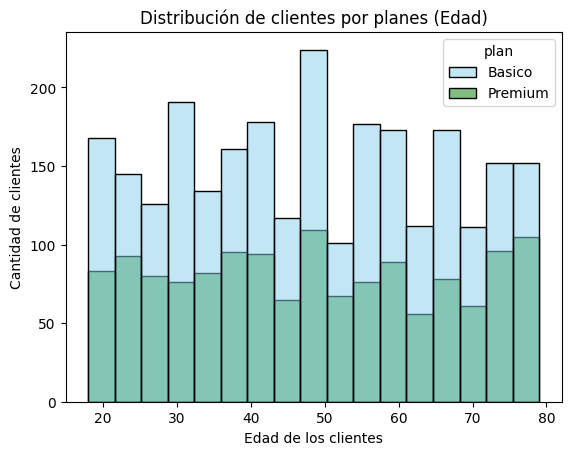

In [50]:
# Histograma para visualizar la edad (age)
sns.histplot(data=user_profile, x='age', hue='plan', palette=['skyblue','green'])

plt.xlabel('Edad de los clientes')
plt.ylabel('Cantidad de clientes')
plt.title('Distribución de clientes por planes (Edad)')

plt.show()

💡Insights: 
- Referente a la edad de los clientes, en la mayoría de los casos se encuentran a la par entre los planes básico y premium, a excepción de algunos casos como entre las edades de 50 a 54 años donde prevalece el plan premium o en el rango de 29 a 33 años donde destaca el plan básico. Probablemente el plan premium predomina en esas edades porque las personas ya estan más establecidas laboralmente, además de que seguramente ya no tienen hijos que ciudar y pueden permitirse enfocarse más en ellos mismos. Contrario al grupo de 29 a 33 años que podrían estar cambiando de trabajo, ocupandóse de sus hijos e incluso cuidando a sus padres, lo que representa un mayor gasto para ellos no pudiendo quizás adquirir un plan de mayor costo.

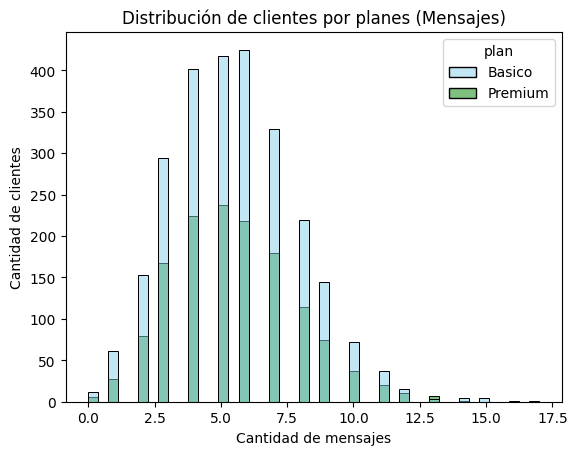

In [51]:
# Histograma para visualizar la cant_mensajes
sns.histplot(data=user_profile, x='cant_mensajes', hue='plan', palette=['skyblue','green'])

plt.xlabel('Cantidad de mensajes')
plt.ylabel('Cantidad de clientes')
plt.title('Distribución de clientes por planes (Mensajes)')

plt.show()

💡Insights: 
- En este histograma de la distribución de los clientes por planes enfocado a mensajes podemos percibir que es una distribución con sesgo a la derecha, ya que la mayoría de los valores se concentran a la izquierda, es decir, en valores bajos y muy pocos estiran la cola hacia la derecha. En los diferentes rangos de cantidad de mensajes se aprecia que en ambos planes los usuarios mandan casi la misma cantidad de mensajes, a excepción por ejemplo en la cantidad de mensajes 12 donde predomina el plan premium o en la cantidad de mensajes 15 donde prevalece el plan básico.

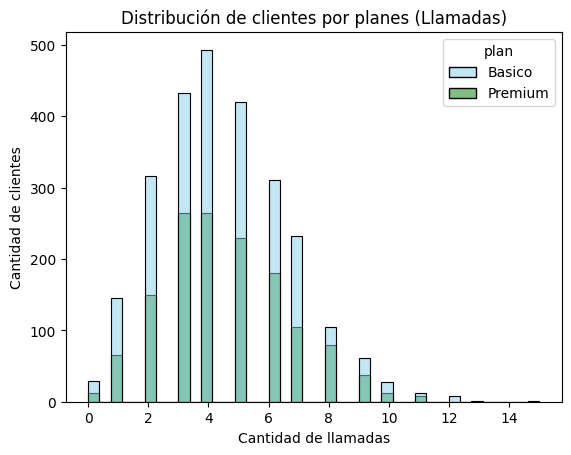

In [52]:
# Histograma para visualizar la cant_llamadas
sns.histplot(data=user_profile, x='cant_llamadas', hue='plan', palette=['skyblue','green'])

plt.xlabel('Cantidad de llamadas')
plt.ylabel('Cantidad de clientes')
plt.title('Distribución de clientes por planes (Llamadas)')

plt.show()

💡Insights: 
- En el histograma de la distribución de clientes por planes enfocado a llamadas, podríamos decir que es aproximadamente simétrica, ya que aunque los valores son similares partiendo desde el punto más alto de la campana, tiene un ligero sesgo a la derecha, y que algunos pocos valores altos jalan la cola hacia este lado. Ambos planes presentan casi la misma cantidad de llamadas, a excepción de cuando la cantidad de llamadas es 8, 9 u 11 que predomina el plan premium, o cuando la cantidad es 12 que destaca el plan básico, quizás por alguna promoción que se les dé a los clientes por llegar justamente a este número de llamadas o algún otro beneficio que valga la pena aprovechar.

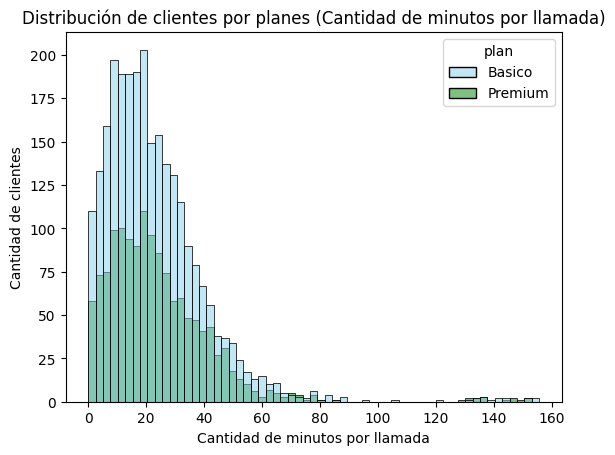

In [53]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data=user_profile, x='cant_minutos_llamada', hue='plan', palette=['skyblue','green'])

plt.xlabel('Cantidad de minutos por llamada')
plt.ylabel('Cantidad de clientes')
plt.title('Distribución de clientes por planes (Cantidad de minutos por llamada)')

plt.show()

💡Insights: 
- En el histograma de distribución de clientes por planes enfocado en la cantidad de minutos por llamada encontramos un evidente sesgo a la derecha, ya que la mayoría de los valores se encuentran en las cantidades más bajas y muy pocos en las altas que estiran la cola a la derecha. En los valores más bajos de cantidad de minutos por llamada en ambos planes presentan cantidades muy similares. Sin embargo, cuando se van incrementando estos minutos en algunos casos el plan premium predomina como es el caso de 40 a 58 minutos, en 64, 70 a 75 minutos y en algunos otros números de la cola. Contrario al predominio del plan básico que resalta solamente en muy pocos casos como en 60, 85, 90, 142 y 155 minutos.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

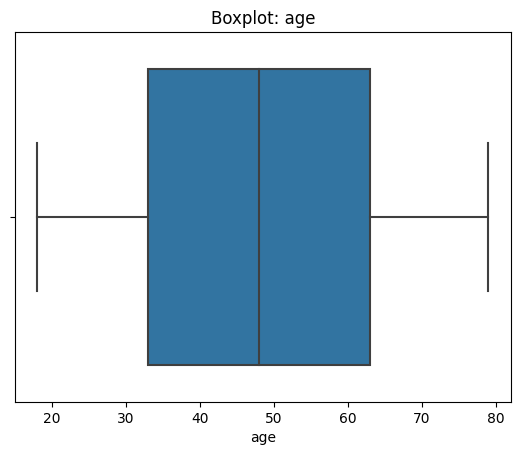

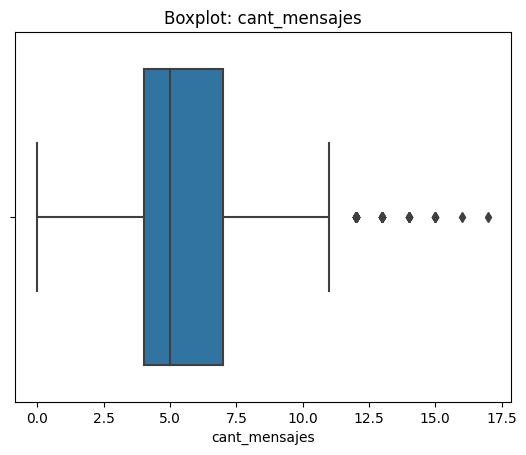

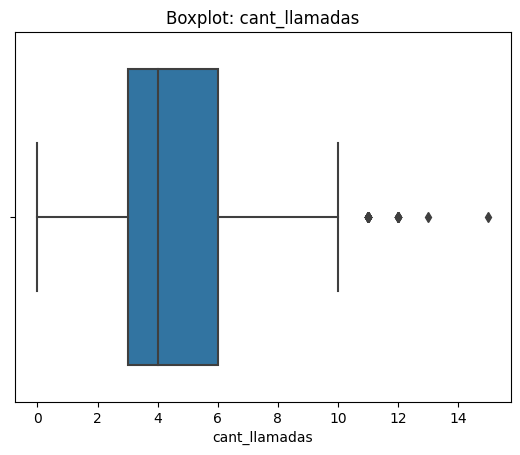

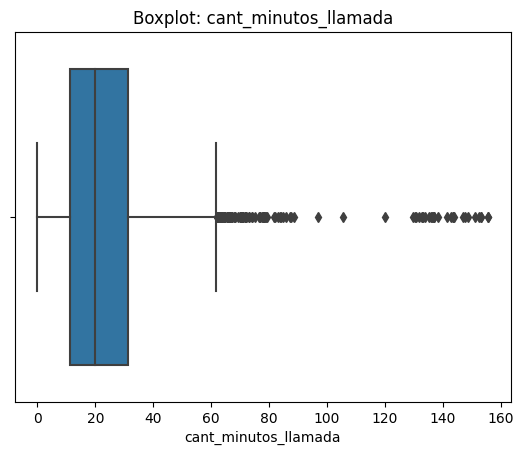

In [54]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for i, col in enumerate(columnas_numericas):
    sns.boxplot(data=user_profile, x=col)
    plt.title(f'Boxplot: {col}')
    plt.show()

💡Insights: 
- Age: No presenta outliers, su mediana está casi a la mitad del rango de los datos y sus bigotes están en rangos adecuados de aproximadamente 18 y 79 años. Tiene un ligero sesgo a la derecha, ya que la mayoria de los datos estan en valores menores a 50 años. Que no haya outliers en esta variable significa que podemos tener confiaza en que los datos se han registrado correctamente, ya que son edades realistas que podemos encontrar en el mercado.

- cant_mensajes: La media se ubica a la izquierda, lo cual significa que se encuentra sobre los rangos más bajos, en este caso 5.0 mensajes. Los bigotes a ambos extremos presentan casi la misma extensión, a la izquierda 3.5 mensajes aproximadamente y a la derecha 3.0 mensajes aproximadamente. En este caso si se aprecian outliers, aunque no son cantidades extremadamente anormales, pues el máximo presentado es 17 mensajes aproximadamente, comparado con los 11.5 mensajes aproximadamente que abarcan los bigotes. En este caso hay un sesgo a la derecha, ya que la mayoría de los datos se concentran en números bajos. Los usuarios que llegan a 17 mensajes pueden ser usuarios muy activos, probablemente jóvenes que prefieren hoy en día los mensajes de texto en lugar de realizar llamadas, por ello se considera que deben mantenerse de este modo, pues no es un valor tan extremo como 50, por ejemplo.

- cant_llamadas: La media se encuentra a la izquierda del rango de datos, la cual corresponde a 4. El bigote izquierdo abarca desde 0 hasta 3 llamadas aproximadamente, mientras que el derecho va de 6 a 10 llamadas, siendo este último ligeramente mayor. Presenta un sesgo a la derecha por tener algunos outliers en este mismo lado de 11, 12, 13 y 15 llamadas aproximadamente, sin embargo no son cantidades las cuales deban ser preocupantes, ya que puede ser el caso contrario, que en esta ocasión sean personas que prefieran las llamadas a los mensajes de texto, que necesiten hacer más llamadas por sus trabajos o algun otro motivo.

- cant_minutos_llamada: En la cantidad de minutos por llamada se encuentra la media en 20 aproximadamente colocándose a la izquierda del conjunto de datos. El bigote izquierdo abarca de 0 a 10 minutos aproximadamente, mientras que el derecho va de 32 a 62 minutos aproximadamente, siendo este mucho mayor que el primero. Se aprecia que hay sesgo a la derecha por la gran cantidad de outliers que jalan la cola a este extremo encontrando valores que llegan hasta 160 minutos que aunque ciertamente varían en gran medida comparado con los 62 minutos "normales", pueden deberse a causas laborales, que desean aprovechar beneficios por llamadas largas o simplemente que son clientes que realizaron una llamada con seres queridos con los que no habían hablado por mucho tiempo o alguna otra razón.

- A excepción de "age" que es una variable demográfica natural y no de comportamiento o consumo tiende a distribuirse de manera más simétrica; estas tres últimas variables de cantidad de mensajes, cantidad de llamadas y cantidad de minutos por llamada son de comportamiento del cliente. Esto significa que aunque numéricamente existan valores atípicos leves o extremos, pueden ser ciertos ya que dependiendo del estilo de vida de cada cliente habrá casos en que una cantidad de mensajes muy alta en el caso de jóvenes por ejemplo, muchas llamadas de alguien trabaja ofreciendo algún servicio por este medio, o un tiempo muy alta en ellas cuando un cliente llama a alguien con quien no ha tenido contacto por mucho tiempo, sea razonable; aunque en algunas ocasiones puede tratarse de los mismos clientes los presentes en los outliers, también debe tomarse en cuenta que podrían tratarse de diferente dependiendo de su rango de edad, por ejemplo. Sin embargo, es necesario tener en cuenta que a veces estos outliers pueden ser errores al registrar los datos, por lo que la comunicación con quién realiza esta labor y con algunos otros que manipulen estos datos es importante con el objetivo de saber si fue algún error o si podemos considerar verídicos dichos registros.

In [55]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for i, col in enumerate(columnas_limites):
    Q1 = user_profile[col].quantile(0.25)
    print('Primer cuartil: ', Q1)

    Q3 = user_profile[col].quantile(0.75)
    print('Tercer cuartil: ', Q3)

    IQR = Q3 - Q1
    print('IQR: ', IQR)

    
    lower = Q1 - 1.5 * IQR
    print(f'Límite inferior: {col} {lower}')     
    
    upper = Q3 + 1.5 * IQR
    print(f'Límite superior: {col} {upper}')


Primer cuartil:  4.0
Tercer cuartil:  7.0
IQR:  3.0
Límite inferior: cant_mensajes -0.5
Límite superior: cant_mensajes 11.5
Primer cuartil:  3.0
Tercer cuartil:  6.0
IQR:  3.0
Límite inferior: cant_llamadas -1.5
Límite superior: cant_llamadas 10.5
Primer cuartil:  11.12
Tercer cuartil:  31.415
IQR:  20.295
Límite inferior: cant_minutos_llamada -19.322500000000005
Límite superior: cant_minutos_llamada 61.8575


In [56]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights: 
- cant_mensajes: mantener o no outliers, porqué? Referente a la cantidad de mensajes, el límite inferior calculado es -0.5, mientras que el real es 0, presentando una diferencia de 0.5; para el límite superior calculado es 11.5 y el real es 17, teniendo una diferencia de 5.5. Se recomienda mantener los valores debido a que puede ser realista que alguien tenga 0 mensajes si cancelo su plan antes siquiera de usarlo, pero también existe la probabilidad de que alguien haya enviado 17 mensajes si es alguien que prefiere comunicarse de este modo.

- cant_llamadas: mantener o no outliers, porqué? Respecto a la cantidad de llamadas, el límite inferior calculado es -1.5, mientras que el real es 0, presentando una diferencia de 1.5; para el límite superior calculado es 10.5 y el real es 15, teniendo una diferencia de 4.5. De igual modo que en el caso anterior, se recomienda preservar estos registros porque 0 llamadas es un comportamiento real que puede tener un cliente que no usó su servicio y lo canceló, así mismo tener 15 llamadas es válido para aquellos que prefieren o necesitan por su estilo de vida realizar un alto número de éstas.

- cant_minutos_llamada: mantener o no outliers, porqué? Hablando de la cantidad de minutos por llamada, el límite inferior calculado es de -19.32, mientras que el real es 0, presentando una diferencia de 19.32; para el límite superior calculado es 61.85 y el real es 155.69, teniendo una diferencia de 93.84. En este caso se recomienda conservar el outlier mínimo, debido a que si alguien no usó su plan para realizar llamadas es lógico que el registro sea 0 minutos por llamada. Por otro lado, el outlier máximo puede pensarse para quedarse tal cual, imputarse o eliminarse dependiendo de la cantidad de estos mismos que existan, viendo si es un comportamiento único o algo que tiende a repetirse algunas veces ya que, aunque 155.69 minutos esta muy alejado de los 61.85 minutos calculados, puede ser posible, ya que convertido en horas es aproximadamente 2 horas con 35 minutos donde alguien pudo por ejemplo, marcar de noche y olvidar colgar quedándose dormido.

En cada caso la cantidad de outliers varía, así como la distancia que presentan respecto a los valores normales y aunque ambos casos son importantes, es más relevante prestar atención a qué tan lejos están los outliers del límite porque podrían considerarse valores atípicos extremos que afecten la media, la desviación estándar u otros cálculos. Sin embargo, el caso de la cantidad de valores atípicos también es importante porque podemos deducir si son errores de tecleado o si podemos decir que es información confiable en dado caso que sean una cantidad considerable.

In [57]:
#Comprobar cuántas filas tienen 155.69000 en cantidad de minutos por llamada
user_profile[user_profile['cant_minutos_llamada'] >= 155.690000].shape

(1, 11)

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [58]:
# Crear columna grupo_uso
def clasificar_uso(row):
    if row['cant_llamadas'] < 5 and row['cant_mensajes'] < 5:
        return 'Bajo uso'
    elif row['cant_llamadas'] < 10 and row['cant_mensajes'] < 10:
        return 'Uso medio'
    else:
        return 'Alto uso'

user_profile['grupo_uso'] = user_profile.apply(clasificar_uso, axis=1)

In [59]:
 print('grupo_uso' in user_profile.columns)

True


In [60]:
#Ver columnas de user_profile
print(user_profile.columns)

Index(['user_id', 'first_name', 'last_name', 'age', 'city', 'reg_date', 'plan',
       'churn_date', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada',
       'grupo_uso'],
      dtype='object')


In [61]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [62]:
# Crear columna grupo_edad
def clasificar_edad(row):
    if row['age'] < 30:
        return 'Joven'
    elif row['age'] < 60:
        return 'Adulto'
    else:
        return 'Adulto Mayor'

user_profile['grupo_edad'] = user_profile.apply(clasificar_edad, axis=1) 

In [63]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

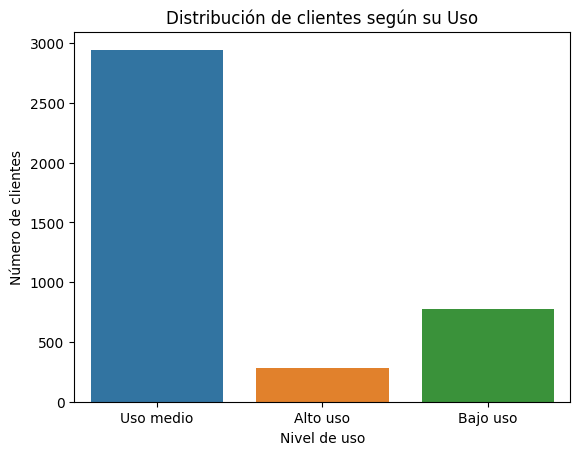

In [64]:
# Visualización de los segmentos por uso
sns.countplot(data=user_profile, x='grupo_uso')
plt.title("Distribución de clientes según su Uso")
plt.xlabel("Nivel de uso") 
plt.ylabel("Número de clientes")

plt.show()

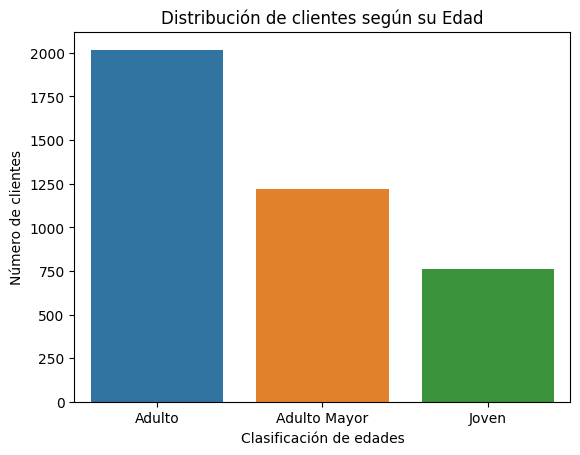

In [65]:
# Visualización de los segmentos por edad
sns.countplot(data=user_profile, x='grupo_edad')
plt.title("Distribución de clientes según su Edad")
plt.xlabel("Clasificación de edades") 
plt.ylabel("Número de clientes")

plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**
En el presente análisis se evaluó el comportamiento de los clientes de una empresa de telecomunicaciones en Latinoamérica llamada ConnectaTel, a través de un proceso que incluía la exploración, limpieza y análisis de datos para construir un perfil estadístico de los clientes, detectar comportamientos atípicos y crear una segmentación de clientes basada en la edad y comportamiento. Todo este proceso permitió identificar patrones de consumo, diseñar estrategias de retención y sugerir mejoras en los distintos planes ofrecidos por la empresa. Los datos analizados abarcaron desde el año 2022 hasta el 2024 y se encontraron en 3 datasets: el primero llamado "plans" donde había datos relevantes de los planes que ofrece a compañía, su precio, minutos incluidos, GB incluidos, costo extra, etc.; el segundo nombrado "users" que incluía información de los clientes como su nombre, edad, ciudad, fecha de regisrtro, plan y fecha de dada de baja (churn); así como "usage" donde se presentó registros sobre el uso real de los servicios como el número de llamadas y mensajes realizados por cliente, el número de minutos por llamada y demás.

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- Los problemas encontrados en los datos fueron primeramente en el dataframe "users" donde habían valores nulos en las columnas: city con 469 representando un 0.11% y churn date (fecha de dada de baja) con 3,534 representando un 0.88% de un total de 4,000 registros para ambas. Los nulos en la columna city se manejaron como "NA", mientras que los registros de churn date al referirse a fechas de dadas de baja, se optó por dejarlos vacios, ya que eso significa que los usuarios siguen usando su servicio.
  
- En la tabla "usage" habían valores nulos en 3 columnas: date con 50 siendo un 0.00125%, duration con 22,076 representando un 0.55% y length con 17,896 siendo un 0.44% de un total de 40,000 registros cada columna. Se optó por dejarlos sin modificar.

- Con respecto a valores inválidos, en el dataframe "users" en su columna age había un error en la edad mínima que era de -999.00, la cual se reemplazó con la mediana.

- Al momento de estandarizar las fechas se encontró que en la tabla "users" en su columna reg data habían 40 registros (de 4,000 en total, representando el 1%) de fechas con años de 2026, siendo que solo se incluían fechas hasta 2024, las cuales se transformaron a "NA".

- Respecto a los sentinels, estos se encontraron en también en el dataframe "users", pero en la columna city con un total de 96 registros de"?" representando el 2.4%, las cuales se transformaron a "NA".


🔍 **Segmentos por Edad**
- Se realizaron dos clases de segmentación de clientes, la primera estuvo enfocada en la edad, donde se llegó a la conclusión de que la población de "Adulto" es la más grande en proporción con más o menos 2000 clientes, siguiendo la clasificación de "Adulto Mayor" con aproximadamente 1250 clientes y por último la población "Joven" con un aproximado de 750 clientes.


📊 **Segmentos por Nivel de Uso**
-  La segunda referente al uso de cantidad de llamadas y mensajes donde se clasificaba a cada cliente en "Bajo uso" cuando las llamadas realizadas eran menores a 5 y los mensajes enviados también menores a 5, en "Uso medio" cuando tanto mensajes como llamadas eran menores a 10 y en "Alto uso" para el resto de los casos. Con esta segmentación se encontró que la mayoría de los clientes se sitúan en "Uso medio" siendo alrededor de 2900, siguiendo en número los que se encuentran en "Bajo uso" con aproximadamente 800 clientes y en "Alto uso" con un aproximado de 300 clientes.


Con el análisis realizado se descubrió que plan "Básico" es el preferido por los usuarios representando el 63.94%, mientras que el "Premium" lo tiene el 36.05% de los clientes. Respecto a la clasificación de edades, de 29 a 33 aproximadamente destaca el plan "Básico", mientras que entre 50 a 54 años prevalece el plan "Premium".

💡 **Recomendaciones**
- Debido a que la mayoría de los clientes se localizan en "Uso medio" y la población "Adulto" es la más grande se recomienda priorizar la mejora del plan "Básico" ya que es el más utilizado según el análisis por este tipo de clientes. Esto puede lograrse a través de primeramente una mayor promoción del plan Básico realizando campañas enfocadas en jóvenes adultos y adultos de entre 29 a 33 años, ya que entre este rango de edad es donde el plan destaca, a pesar de que la categoría "Adulto" abarque de 30 a 59 años, con el objetivo de que conozcan los beneficios que se cuentan con su contratación. Así mismo, podrían ofrecerse GB gratis de regalo durante un tiempo determinado por unirse al plan, un mes gratis con el plan y pagar hasta el segundo o una mayor cobertura si se viaja al extrajero por ejemplo, con el objetivo de atraer más clientes de este segmento.
  
- Por otro lado, si se quisiera incrementar el segmento de quienes usan el plan "Premium" se necesitaría la realización de campañas enfocadas a un rango de edad entre 50 a 54 años, es decir a adultos maduros en lugar de a la clasificación de "Adulto Mayor" que inicialmente parecía ser el grupo con mayor uso de "Premium" según los gráficos generales, pues es donde se encuentra el mayor uso de este plan. Debido a que son adultos maduros podría realizarse la combinación de medios físicos y medios electrónicos para la promoción de este plan con el objetivo de llegar tanto a quiénes ya estan inmersos en el mundo de la tecnología y a quiénes aun estan en proceso de realizarlo.


- En resumen, promocionar el plan "Básico" y ofrecer beneficios entre jóvenes adultos y adultos, así como promocionar a través de medios híbridos el plan "Premium" entre adultos maduros parecen ser las mejores estrategias para atraer nuevos clientes; sin olvidar brindar un servicio de calidad a los clientes que ya se tienen con el propósito de evitar lo mayor posible la cancelación de los servicios.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`